# 🌊 AquaGuard – Water Leakage Detection System

**Theme:** SDG 6 – Clean Water and Sanitation  
**Curriculum Focus:** Python Basics, Classes (OOP), Linear Search, Arithmetic Operations

---

This notebook builds a city-wide water sensor monitoring system that automatically detects leaks, pressure anomalies, and burst pipes.

## Cell 1 — Imports & Configuration

In [2]:
# ============================================================
# Cell 1: Imports & Configuration
# ============================================================

import random
import csv
import os
import matplotlib.pyplot as plt
import matplotlib

# --- Configuration Constants ---
TOTAL_SENSORS = 400
ANOMALY_PERCENTAGE = 0.08          # 8% anomalous (above the 5% minimum)
PRESSURE_SAFETY_THRESHOLD = 80     # PSI
BASELINE_MIN = 10.0                # LPM - minimum baseline for burst detection

# City zones for sensor deployment
ZONES = [
    "Residential_A", "Residential_B",
    "Industrial_A",  "Industrial_B",
    "Commercial_A",  "Commercial_B",
    "Municipal_A",   "Downtown_A"
]

# Zone prefixes for sensor IDs
ZONE_PREFIXES = {
    "Residential_A": "S_RA", "Residential_B": "S_RB",
    "Industrial_A":  "S_IA", "Industrial_B":  "S_IB",
    "Commercial_A":  "S_CA", "Commercial_B":  "S_CB",
    "Municipal_A":   "S_MA", "Downtown_A":    "S_DA"
}

# Flow-rate ranges per zone type (baseline_min, baseline_max)
ZONE_FLOW_RANGES = {
    "Residential_A": (10, 30),   "Residential_B": (10, 30),
    "Industrial_A":  (80, 200),  "Industrial_B":  (80, 200),
    "Commercial_A":  (40, 150),  "Commercial_B":  (40, 150),
    "Municipal_A":   (20, 60),   "Downtown_A":    (30, 100)
}

# Output paths
DATASET_PATH = "sensor_data.csv"
REPORT_PATH  = "leak_report.txt"

# Reproducibility
random.seed(42)

print("✅ Configuration loaded.")
print(f"   Sensors: {TOTAL_SENSORS}  |  Zones: {len(ZONES)}  |  Anomaly target: {ANOMALY_PERCENTAGE*100:.0f}%")

✅ Configuration loaded.
   Sensors: 400  |  Zones: 8  |  Anomaly target: 8%


## Cell 2 — Synthetic Dataset Generation

In [3]:
# ============================================================
# Cell 2: Synthetic Dataset Generation
# ============================================================

def generate_sensor_data(total=TOTAL_SENSORS, anomaly_pct=ANOMALY_PERCENTAGE):
    """
    Generate synthetic sensor readings.
    Returns a list of dicts with keys:
      sensor_id, location_zone, flow_rate_lpm, baseline_mean, pressure_psi
    """
    data = []
    num_anomalies = int(total * anomaly_pct)
    # Half burst anomalies, half pressure anomalies
    num_bursts = num_anomalies // 2
    num_pressure = num_anomalies - num_bursts

    zone_counters = {z: 0 for z in ZONES}

    for i in range(total):
        zone = random.choice(ZONES)
        zone_counters[zone] += 1
        prefix = ZONE_PREFIXES[zone]
        sensor_id = f"{prefix}_{zone_counters[zone]:03d}"

        flow_min, flow_max = ZONE_FLOW_RANGES[zone]
        baseline = round(random.uniform(flow_min, flow_max), 1)

        if i < num_bursts:
            # --- BURST ANOMALY: zero flow, normal pressure ---
            flow_rate = 0.0
            pressure = round(random.uniform(30, 70), 1)
        elif i < num_bursts + num_pressure:
            # --- PRESSURE ANOMALY: high pressure ---
            flow_rate = round(random.uniform(baseline * 0.8, baseline * 1.2), 1)
            pressure = round(random.uniform(81, 120), 1)
        else:
            # --- NORMAL sensor ---
            flow_rate = round(random.uniform(baseline * 0.85, baseline * 1.15), 1)
            pressure = round(random.uniform(30, 75), 1)

        data.append({
            "sensor_id":      sensor_id,
            "location_zone":  zone,
            "flow_rate_lpm":  flow_rate,
            "baseline_mean":  baseline,
            "pressure_psi":   pressure
        })

    # Shuffle so anomalies aren't all at the top
    random.shuffle(data)
    return data


# Generate & save to CSV
sensor_data = generate_sensor_data()

with open(DATASET_PATH, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=[
        "sensor_id", "location_zone", "flow_rate_lpm", "baseline_mean", "pressure_psi"
    ])
    writer.writeheader()
    writer.writerows(sensor_data)

# --- Summary ---
burst_count = sum(1 for s in sensor_data if s["flow_rate_lpm"] == 0.0 and s["baseline_mean"] > BASELINE_MIN)
pressure_count = sum(1 for s in sensor_data if s["pressure_psi"] > PRESSURE_SAFETY_THRESHOLD)
total_anomalies = burst_count + pressure_count

print(f"✅ Dataset generated: {len(sensor_data)} sensors → '{DATASET_PATH}'")
print(f"   Major Bursts:     {burst_count}")
print(f"   Pressure Alerts:  {pressure_count}")
print(f"   Total Anomalies:  {total_anomalies} ({total_anomalies/len(sensor_data)*100:.1f}%)")
print(f"\n📋 Sample rows:")
for row in sensor_data[:5]:
    print(f"   {row}")

✅ Dataset generated: 400 sensors → 'sensor_data.csv'
   Major Bursts:     16
   Pressure Alerts:  16
   Total Anomalies:  32 (8.0%)

📋 Sample rows:
   {'sensor_id': 'S_IB_001', 'location_zone': 'Industrial_B', 'flow_rate_lpm': 0.0, 'baseline_mean': 96.7, 'pressure_psi': 34.1}
   {'sensor_id': 'S_MA_002', 'location_zone': 'Municipal_A', 'flow_rate_lpm': 0.0, 'baseline_mean': 33.6, 'pressure_psi': 36.2}
   {'sensor_id': 'S_DA_015', 'location_zone': 'Downtown_A', 'flow_rate_lpm': 66.1, 'baseline_mean': 61.5, 'pressure_psi': 67.8}
   {'sensor_id': 'S_CA_029', 'location_zone': 'Commercial_A', 'flow_rate_lpm': 114.4, 'baseline_mean': 104.3, 'pressure_psi': 72.3}
   {'sensor_id': 'S_RA_025', 'location_zone': 'Residential_A', 'flow_rate_lpm': 20.6, 'baseline_mean': 22.4, 'pressure_psi': 51.3}


## Cell 3 — Sensor Class (OOP)

In [4]:
# ============================================================
# Cell 3: Sensor Class (Object-Oriented Programming)
# ============================================================

class Sensor:
    """
    Represents a single water-network sensor node.

    Attributes:
        sensor_id     (str):   Unique identifier
        location_zone (str):   City zone the sensor is deployed in
        flow_rate_lpm (float): Current observed flow rate (litres per minute)
        baseline_mean (float): Expected normal flow rate
        pressure_psi  (float): Current pressure reading
    """

    def __init__(self, sensor_id: str, location_zone: str,
                 flow_rate_lpm: float, baseline_mean: float,
                 pressure_psi: float):
        self.sensor_id     = sensor_id
        self.location_zone = location_zone
        self.flow_rate_lpm = flow_rate_lpm
        self.baseline_mean = baseline_mean
        self.pressure_psi  = pressure_psi

    def check_status(self) -> str:
        """
        Evaluate the sensor reading and return the anomaly type.

        Returns:
            'Major Burst'      — flow is 0.0 while baseline > 10.0
            'Pressure Alert'   — pressure exceeds 80 PSI
            'Normal'           — no anomaly detected
        """
        if self.flow_rate_lpm == 0.0 and self.baseline_mean > BASELINE_MIN:
            return "Major Burst"
        if self.pressure_psi > PRESSURE_SAFETY_THRESHOLD:
            return "Pressure Alert"
        return "Normal"

    def report_leak(self) -> str:
        """
        Generate a human-readable maintenance alert string.

        Returns a formatted string if anomaly detected, or a 'Normal' status line.
        """
        status = self.check_status()

        if status == "Major Burst":
            return (
                f"🚨 MAJOR BURST  |  Sensor: {self.sensor_id}  |  "
                f"Zone: {self.location_zone}  |  "
                f"Flow: {self.flow_rate_lpm} LPM (baseline: {self.baseline_mean} LPM)  |  "
                f"Pressure: {self.pressure_psi} PSI"
            )

        if status == "Pressure Alert":
            exceed_pct = round(
                ((self.pressure_psi - PRESSURE_SAFETY_THRESHOLD)
                 / PRESSURE_SAFETY_THRESHOLD) * 100, 1
            )
            return (
                f"⚠️  PRESSURE ALERT  |  Sensor: {self.sensor_id}  |  "
                f"Zone: {self.location_zone}  |  "
                f"Pressure: {self.pressure_psi} PSI  |  "
                f"Exceeds safety threshold by {exceed_pct}%"
            )

        return f"✅ NORMAL  |  Sensor: {self.sensor_id}  |  Zone: {self.location_zone}"

    def __repr__(self):
        return (f"Sensor(id={self.sensor_id}, zone={self.location_zone}, "
                f"flow={self.flow_rate_lpm}, baseline={self.baseline_mean}, "
                f"psi={self.pressure_psi})")


# --- Quick demo ---
demo = Sensor("S_DEMO_001", "Test_Zone", 0.0, 50.0, 45.0)
print(f"Demo sensor: {demo}")
print(f"Status:      {demo.check_status()}")
print(f"Report:      {demo.report_leak()}")
print("\n✅ Sensor class defined.")

Demo sensor: Sensor(id=S_DEMO_001, zone=Test_Zone, flow=0.0, baseline=50.0, psi=45.0)
Status:      Major Burst
Report:      🚨 MAJOR BURST  |  Sensor: S_DEMO_001  |  Zone: Test_Zone  |  Flow: 0.0 LPM (baseline: 50.0 LPM)  |  Pressure: 45.0 PSI

✅ Sensor class defined.


## Cell 4 — Linear Search Detection Engine

In [5]:
# ============================================================
# Cell 4: Linear Search Detection Engine
# ============================================================

def load_sensors_from_data(data: list) -> list:
    """Convert list of dicts into list of Sensor objects."""
    return [
        Sensor(
            sensor_id=row["sensor_id"],
            location_zone=row["location_zone"],
            flow_rate_lpm=row["flow_rate_lpm"],
            baseline_mean=row["baseline_mean"],
            pressure_psi=row["pressure_psi"]
        )
        for row in data
    ]


def detect_anomalies(sensors: list) -> list:
    """
    Linear search through ALL sensors.
    Returns a list of (sensor, status) tuples for flagged sensors.
    """
    flagged = []
    for sensor in sensors:           # Linear scan — no skipping
        status = sensor.check_status()
        if status != "Normal":
            flagged.append((sensor, status))
    return flagged


# --- Run detection ---
all_sensors = load_sensors_from_data(sensor_data)
flagged_sensors = detect_anomalies(all_sensors)

# Categorise
bursts   = [(s, st) for s, st in flagged_sensors if st == "Major Burst"]
pressures = [(s, st) for s, st in flagged_sensors if st == "Pressure Alert"]

print(f"🔍 Scanned {len(all_sensors)} sensors via linear search.")
print(f"   🚨 Major Bursts:     {len(bursts)}")
print(f"   ⚠️  Pressure Alerts:  {len(pressures)}")
print(f"   📊 Total Flagged:     {len(flagged_sensors)}")
print(f"\n--- First 5 flagged sensors ---")
for sensor, status in flagged_sensors[:5]:
    print(f"   [{status}] {sensor.sensor_id} @ {sensor.location_zone}")

🔍 Scanned 400 sensors via linear search.
   🚨 Major Bursts:     16
   ⚠️  Pressure Alerts:  16
   📊 Total Flagged:     32

--- First 5 flagged sensors ---
   [Major Burst] S_IB_001 @ Industrial_B
   [Major Burst] S_MA_002 @ Municipal_A
   [Pressure Alert] S_CB_005 @ Commercial_B
   [Pressure Alert] S_CB_004 @ Commercial_B
   [Pressure Alert] S_IB_002 @ Industrial_B


## Cell 5 — Generate Leak Report

In [6]:
# ============================================================
# Cell 5: Generate leak_report.txt
# ============================================================

def generate_leak_report(flagged: list, path: str = REPORT_PATH):
    """
    Write a formatted leak report to a text file.
    Each line: Sensor ID | Zone | Anomaly Type | Details
    """
    with open(path, "w") as f:
        f.write("=" * 80 + "\n")
        f.write("  AQUAGUARD — WATER LEAKAGE DETECTION REPORT\n")
        f.write("=" * 80 + "\n\n")
        f.write(f"Total Sensors Scanned:  {TOTAL_SENSORS}\n")
        f.write(f"Total Anomalies Found:  {len(flagged)}\n")
        f.write(f"Anomaly Rate:           {len(flagged)/TOTAL_SENSORS*100:.1f}%\n")
        f.write("\n" + "-" * 80 + "\n\n")

        # Major Bursts section
        f.write("🚨 MAJOR BURSTS\n")
        f.write("-" * 40 + "\n")
        burst_items = [(s, st) for s, st in flagged if st == "Major Burst"]
        if burst_items:
            for sensor, status in burst_items:
                f.write(
                    f"  {sensor.sensor_id:<12} | {sensor.location_zone:<16} | "
                    f"Flow: {sensor.flow_rate_lpm} LPM | "
                    f"Baseline: {sensor.baseline_mean} LPM | "
                    f"Pressure: {sensor.pressure_psi} PSI\n"
                )
        else:
            f.write("  (none detected)\n")

        f.write("\n")

        # Pressure Alerts section
        f.write("⚠️  PRESSURE ALERTS\n")
        f.write("-" * 40 + "\n")
        pressure_items = [(s, st) for s, st in flagged if st == "Pressure Alert"]
        if pressure_items:
            for sensor, status in pressure_items:
                exceed_pct = round(
                    ((sensor.pressure_psi - PRESSURE_SAFETY_THRESHOLD)
                     / PRESSURE_SAFETY_THRESHOLD) * 100, 1
                )
                f.write(
                    f"  {sensor.sensor_id:<12} | {sensor.location_zone:<16} | "
                    f"Pressure: {sensor.pressure_psi} PSI | "
                    f"Exceeds by: {exceed_pct}%\n"
                )
        else:
            f.write("  (none detected)\n")

        f.write("\n" + "=" * 80 + "\n")
        f.write("  END OF REPORT\n")
        f.write("=" * 80 + "\n")

    return path


# Generate the report
report_path = generate_leak_report(flagged_sensors)

# Display it
print(f"✅ Report saved to '{report_path}'\n")
with open(report_path) as f:
    print(f.read())

✅ Report saved to 'leak_report.txt'

  AQUAGUARD — WATER LEAKAGE DETECTION REPORT

Total Sensors Scanned:  400
Total Anomalies Found:  32
Anomaly Rate:           8.0%

--------------------------------------------------------------------------------

🚨 MAJOR BURSTS
----------------------------------------
  S_IB_001     | Industrial_B     | Flow: 0.0 LPM | Baseline: 96.7 LPM | Pressure: 34.1 PSI
  S_MA_002     | Municipal_A      | Flow: 0.0 LPM | Baseline: 33.6 LPM | Pressure: 36.2 PSI
  S_RB_002     | Residential_B    | Flow: 0.0 LPM | Baseline: 21.8 LPM | Pressure: 31.3 PSI
  S_RB_003     | Residential_B    | Flow: 0.0 LPM | Baseline: 14.4 LPM | Pressure: 50.2 PSI
  S_RB_001     | Residential_B    | Flow: 0.0 LPM | Baseline: 10.5 LPM | Pressure: 41.0 PSI
  S_CB_003     | Commercial_B     | Flow: 0.0 LPM | Baseline: 103.5 LPM | Pressure: 58.2 PSI
  S_MA_001     | Municipal_A      | Flow: 0.0 LPM | Baseline: 28.8 LPM | Pressure: 53.6 PSI
  S_CB_001     | Commercial_B     | Flow: 0.0 LPM

## Cell 6 — Visualization

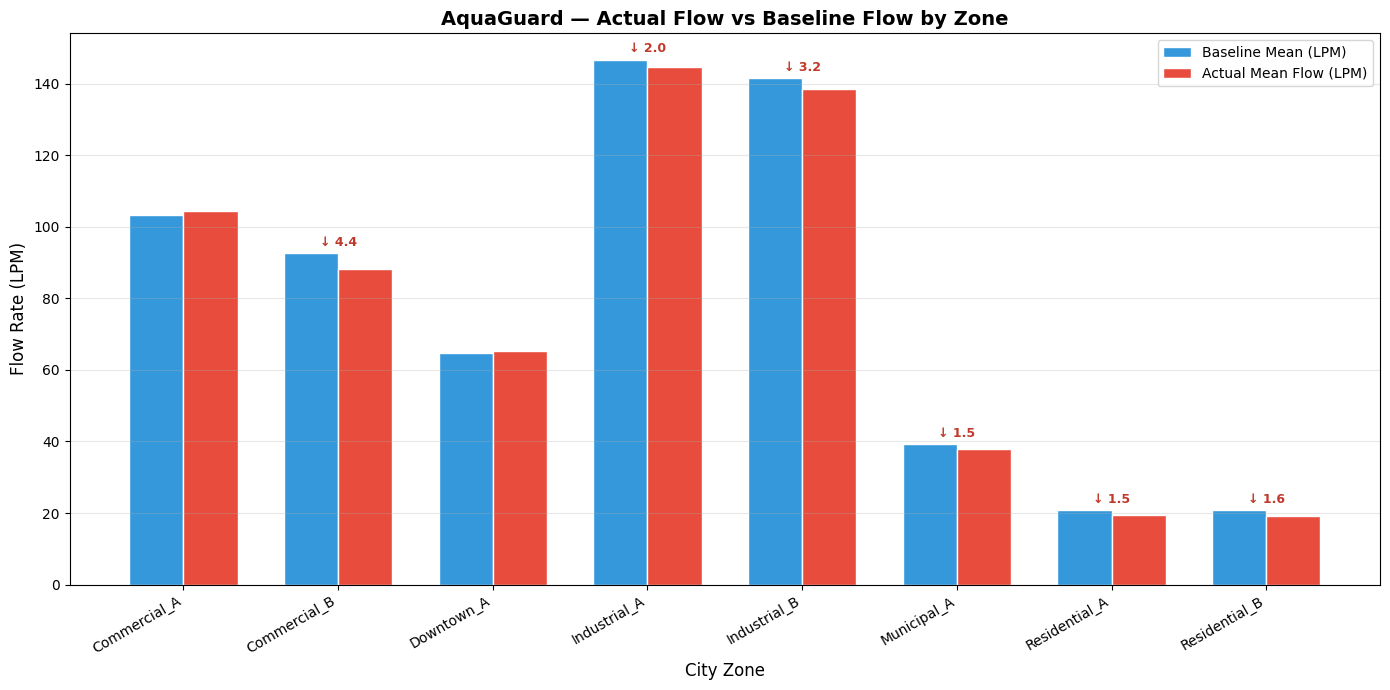


✅ Chart saved to 'flow_comparison.png'


In [7]:
# ============================================================
# Cell 6: Visualization — Actual Flow vs Baseline by Zone
# ============================================================

def plot_flow_comparison(sensors: list):
    """
    Grouped bar chart: mean actual flow vs mean baseline per zone.
    Highlights zones with highest water loss.
    """
    # Aggregate by zone
    zone_actual = {}
    zone_baseline = {}
    zone_counts = {}

    for s in sensors:
        z = s.location_zone
        zone_actual[z]   = zone_actual.get(z, 0) + s.flow_rate_lpm
        zone_baseline[z] = zone_baseline.get(z, 0) + s.baseline_mean
        zone_counts[z]   = zone_counts.get(z, 0) + 1

    zones = sorted(zone_counts.keys())
    avg_actual   = [round(zone_actual[z] / zone_counts[z], 1) for z in zones]
    avg_baseline = [round(zone_baseline[z] / zone_counts[z], 1) for z in zones]
    water_loss   = [round(b - a, 1) for a, b in zip(avg_actual, avg_baseline)]

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(14, 7))

    x = range(len(zones))
    bar_width = 0.35

    bars1 = ax.bar([i - bar_width/2 for i in x], avg_baseline, bar_width,
                    label="Baseline Mean (LPM)", color="#3498db", edgecolor="white")
    bars2 = ax.bar([i + bar_width/2 for i in x], avg_actual, bar_width,
                    label="Actual Mean Flow (LPM)", color="#e74c3c", edgecolor="white")

    # Water-loss annotation
    for i, loss in enumerate(water_loss):
        if loss > 0:
            ax.annotate(f"↓ {loss}",
                        xy=(i, max(avg_actual[i], avg_baseline[i]) + 2),
                        ha="center", fontsize=9, color="#c0392b", fontweight="bold")

    ax.set_xlabel("City Zone", fontsize=12)
    ax.set_ylabel("Flow Rate (LPM)", fontsize=12)
    ax.set_title("AquaGuard — Actual Flow vs Baseline Flow by Zone",
                  fontsize=14, fontweight="bold")
    ax.set_xticks(list(x))
    ax.set_xticklabels(zones, rotation=30, ha="right")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig("flow_comparison.png", dpi=150)
    plt.show()
    print("\n✅ Chart saved to 'flow_comparison.png'")


plot_flow_comparison(all_sensors)

## Cell 7 — Test Cases & Validation

In [8]:
# ============================================================
# Cell 7: Test Cases & Validation
# ============================================================

print("Running test cases...\n")
all_passed = True

# --- Test 1: Leak / Burst Detection ---
print("TEST 1 — Major Burst Detection")
t1 = Sensor("T_001", "Test_Zone", flow_rate_lpm=0.0,
            baseline_mean=50.0, pressure_psi=45.0)
result = t1.check_status()
if result == "Major Burst":
    print(f"   ✅ PASSED: flow=0.0, baseline=50.0 → '{result}'")
else:
    print(f"   ❌ FAILED: expected 'Major Burst', got '{result}'")
    all_passed = False

# Edge case: zero flow but baseline <= 10 should NOT flag
t1b = Sensor("T_001B", "Test_Zone", flow_rate_lpm=0.0,
             baseline_mean=5.0, pressure_psi=45.0)
result_b = t1b.check_status()
if result_b == "Normal":
    print(f"   ✅ PASSED: flow=0.0, baseline=5.0 → '{result_b}' (correctly ignored)")
else:
    print(f"   ❌ FAILED: expected 'Normal', got '{result_b}'")
    all_passed = False

print()

# --- Test 2: Object Isolation / Encapsulation ---
print("TEST 2 — Object Isolation (no shared state)")
s_a = Sensor("T_002A", "Zone_X", flow_rate_lpm=100.0,
             baseline_mean=100.0, pressure_psi=50.0)
s_b = Sensor("T_002B", "Zone_Y", flow_rate_lpm=200.0,
             baseline_mean=200.0, pressure_psi=60.0)

# Mutate sensor A
s_a.flow_rate_lpm = 0.0
s_a.pressure_psi = 90.0

if s_b.flow_rate_lpm == 200.0 and s_b.pressure_psi == 60.0:
    print(f"   ✅ PASSED: Modifying sensor A did NOT affect sensor B")
    print(f"      A → flow={s_a.flow_rate_lpm}, psi={s_a.pressure_psi}")
    print(f"      B → flow={s_b.flow_rate_lpm}, psi={s_b.pressure_psi}")
else:
    print(f"   ❌ FAILED: Sensor B was affected by changes to Sensor A")
    all_passed = False

print()

# --- Test 3: Pressure Alert with % Calculation ---
print("TEST 3 — Pressure Alert (% exceeds threshold)")
t3 = Sensor("T_003", "Test_Zone", flow_rate_lpm=80.0,
            baseline_mean=80.0, pressure_psi=100.0)
report = t3.report_leak()
expected_pct = ((100.0 - 80) / 80) * 100  # = 25.0%
if "25.0%" in report and "PRESSURE ALERT" in report:
    print(f"   ✅ PASSED: pressure=100 PSI → exceeds by {expected_pct}%")
    print(f"      Report: {report}")
else:
    print(f"   ❌ FAILED: report does not contain expected '25.0%'")
    print(f"      Got: {report}")
    all_passed = False

# Additional: verify exact boundary (81 PSI)
t3b = Sensor("T_003B", "Test_Zone", flow_rate_lpm=80.0,
             baseline_mean=80.0, pressure_psi=80.0)
if t3b.check_status() == "Normal":
    print(f"   ✅ PASSED: pressure=80 PSI (exactly at threshold) → 'Normal'")
else:
    print(f"   ❌ FAILED: pressure=80 should be 'Normal', got '{t3b.check_status()}'")
    all_passed = False

print()
print("=" * 50)
if all_passed:
    print("🎉 ALL TESTS PASSED!")
else:
    print("⚠️  SOME TESTS FAILED — review output above.")
print("=" * 50)

Running test cases...

TEST 1 — Major Burst Detection
   ✅ PASSED: flow=0.0, baseline=50.0 → 'Major Burst'
   ✅ PASSED: flow=0.0, baseline=5.0 → 'Normal' (correctly ignored)

TEST 2 — Object Isolation (no shared state)
   ✅ PASSED: Modifying sensor A did NOT affect sensor B
      A → flow=0.0, psi=90.0
      B → flow=200.0, psi=60.0

TEST 3 — Pressure Alert (% exceeds threshold)
   ✅ PASSED: pressure=100 PSI → exceeds by 25.0%
      Report: ⚠️  PRESSURE ALERT  |  Sensor: T_003  |  Zone: Test_Zone  |  Pressure: 100.0 PSI  |  Exceeds safety threshold by 25.0%
   ✅ PASSED: pressure=80 PSI (exactly at threshold) → 'Normal'

🎉 ALL TESTS PASSED!
